# Neural machine translation: LSTM only

In this demo, we build a English-French seq2seq translation model. Some of the key implementation details are:

1. **Subword tokenization** - Word-level tokenization creates massive vocabularies and can't handle unseen words. We use SentencePiece subword tokenization (~60K tokens) to handle any input while capturing common patterns.

2. **Real training data** - We use 100,000 sentence pairs from the OPUS-100 English-French corpus instead of 15 hand-crafted phrases.

3. **Bidirectional encoder** - Capture context from both directions for better source understanding.

4. **BLEU evaluation** - Translation quality is measured using BLEU (Bilingual Evaluation Understudy) score, which compares n-gram overlap between model outputs and reference translations. BLEU computes a score between 0 and 100 based on:
   - **N-gram precision**: How many n-grams (1-4 words) from the model output appear in the reference translation, averaged using geometric mean
   - **Brevity penalty**: Exponentially penalizes translations that are too short (which would otherwise artificially inflate precision)
   - **Corpus-level aggregation**: Combines statistics across many sentences for reliable evaluation
   
   BLEU scores above 60 indicate very high quality translation, 40-60 is good, 20-40 is mediocre, and below 20 is poor. While BLEU has limitations (e.g., doesn't capture meaning or fluency perfectly), it's fast, automated, and correlates reasonably well with human judgment, making it ideal for monitoring training progress.

### References

The encoder-decoder architecture for neural machine translation was introduced in:

> Sutskever, I., Vinyals, O., & Le, Q. V. (2014). **Sequence to sequence learning with neural networks.** *Advances in Neural Information Processing Systems, 27.* https://arxiv.org/abs/1409.3215

The OPUS-100 dataset used in this activity:

> Zhang, B., Williams, P., Titov, I., & Sennrich, R. (2020). **Improving massively multilingual neural machine translation and zero-shot translation.** *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (ACL).* https://arxiv.org/abs/2004.11867

## Notebook set-up

### Imports

In [ ]:
# Suppress TensorFlow warnings and select GPU
import logging
import os
import sys
from datetime import datetime

# Environment variables for TensorFlow. Note: these must
# be set BEFORE importing TensorFlow to take effect.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress TensorFlow warnings
os.environ['CUDA_VISIBLE_DEVICES'] = '1' # Select GPU, 0 for GPU 1, etc.

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# NLP and translation libraries
from datasets import load_dataset
from sacrebleu.metrics import BLEU
from transformers import MarianTokenizer

# Keras model components
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Embedding,
    Bidirectional, Concatenate
)

from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard, ReduceLROnPlateau

### Configuration

In [2]:
# Configure GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Disable Jupyter widgets to prevent rendering issues after reopening notebook
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '0'  # Keep progress bars but use plain text

# Set event level output filter for TensorFlow
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Add parent directory to sys.path to allow importing from src module
sys.path.append('..')

# Initialization
np.random.seed(315)
tf.random.set_seed(315)

## 1. Prepare assets

Using the OPUS-100 English-French translation corpus from Hugging Face datasets with subword tokenization (SentencePiece). Subword tokenization is essential for NMT (Neural Machine Translation) because it:
- Vocabulary size: ~60K subword tokens
- Handles rare/unseen words by breaking them into known subwords
- Shares subword units across related words (e.g., "play", "playing", "played")

### 1.1. Load tokenizer

In [3]:
# Load pre-trained subword tokenizer (SentencePiece)
# MarianTokenizer is specifically designed for the Helsinki-NLP translation models
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr', cache_dir='../models/')

print(f'Tokenizer vocabulary size: {tokenizer.vocab_size}')
print(f'Special tokens: {tokenizer.special_tokens_map}')

# Example of subword tokenization
example = 'The neural network learned representations'
tokens = tokenizer.tokenize(example)
print(f'\nExample tokenization:')
print(f'  Input: "{example}"')
print(f'  Tokens: {tokens}')

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Tokenizer vocabulary size: 59514
Special tokens: {'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}

Example tokenization:
  Input: "The neural network learned representations"
  Tokens: ['▁The', '▁ne', 'ural', '▁network', '▁learned', '▁representations']


### 1.2. Load dataset

In [4]:
# Load OPUS-100 English-French translation dataset
dataset = load_dataset('Helsinki-NLP/opus-100', 'en-fr', cache_dir='../data/')

# Extract translation pairs and filter by token length
pairs = []
max_seq_length = 20  # Maximum tokens per sentence

for item in dataset['train']:

    en_text = item['translation']['en'].strip()
    fr_text = item['translation']['fr'].strip()
    
    # Check token length using tokenize() to avoid truncation warnings
    en_tokens = tokenizer.tokenize(en_text)
    fr_tokens = tokenizer.tokenize(fr_text)
    
    if len(en_tokens) <= max_seq_length and len(fr_tokens) <= max_seq_length:
        pairs.append((en_text, fr_text))
    
    # Limit dataset size for reasonable training time
    if len(pairs) >= 100000:
        break

print(f'Loaded {len(pairs)} translation pairs')
print(f'\nSample pairs:')

for en, fr in pairs[1:5]:
    print()
    print(f'  EN: {en}')
    print(f'  FR: {fr}')

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loaded 100000 translation pairs

Sample pairs:

  EN: Hello, what's that?
  FR: Qu'est-ce que c'est que ça ?

  EN: And then I will teach you everything i know.
  FR: Et alors, je t'apprendrai tout ce que je sais.

  EN: Did you find something?
  FR: Par ici !

  EN: Article 6
  FR: Article 6


In [5]:
# Tokenize all pairs using the subword tokenizer
# The tokenizer handles both English and French (it's a multilingual SentencePiece model)
max_encoder_len = 22  # Slightly larger than max_seq_length for special tokens
max_decoder_len = 24

# Tokenize source (English) sentences
encoder_inputs = tokenizer(
    [pair[0] for pair in pairs],
    padding='max_length',
    truncation=True,
    max_length=max_encoder_len,
    return_tensors='np'
)

# Tokenize target (French) sentences
decoder_input_texts = [pair[1] for pair in pairs]

decoder_inputs = tokenizer(
    decoder_input_texts,
    padding='max_length',
    truncation=True,
    max_length=max_decoder_len - 1,  # Leave room for BOS token
    return_tensors='np'
)

# Prepare encoder data
encoder_input_data = encoder_inputs['input_ids']

# CRITICAL: Decoder input must start with BOS token (we use pad_token_id)
# This aligns training with inference, where we also start with pad_token_id
# decoder_input: [BOS, tok1, tok2, ..., tokN, pad, pad...]
# decoder_target: [tok1, tok2, ..., tokN, EOS, pad, pad...]
raw_decoder_tokens = decoder_inputs['input_ids']
decoder_input_data = np.full((len(pairs), max_decoder_len), tokenizer.pad_token_id, dtype=np.int32)
decoder_input_data[:, 1:1 + raw_decoder_tokens.shape[1]] = raw_decoder_tokens

# Targets are the original tokens (what we want to predict after BOS)
decoder_target_data = np.full((len(pairs), max_decoder_len), tokenizer.pad_token_id, dtype=np.int32)
decoder_target_data[:, :raw_decoder_tokens.shape[1]] = raw_decoder_tokens

# Model dimensions
num_samples = len(pairs)
num_tokens = tokenizer.vocab_size  # Same vocab for encoder and decoder

print(f'Vocabulary size: {num_tokens}')
print(f'Max encoder length: {max_encoder_len}')
print(f'Max decoder length: {max_decoder_len}')
print(f'Training samples: {num_samples}')
print(f'\nEncoder input shape: {encoder_input_data.shape}')
print(f'Decoder input shape: {decoder_input_data.shape}')
print(f'Decoder target shape: {decoder_target_data.shape}')

Vocabulary size: 59514
Max encoder length: 22
Max decoder length: 24
Training samples: 100000

Encoder input shape: (100000, 22)
Decoder input shape: (100000, 24)
Decoder target shape: (100000, 24)


## 2. Model definitions

This section defines all model components needed for training and evaluation. We build:
1. **Training model**: The encoder-decoder architecture trained on parallel text
2. **Inference models**: Separate encoder and decoder for autoregressive translation
3. **Translation function**: Greedy decoding loop for generating translations
4. **BLEU callback**: Monitors translation quality during training

**Training architecture:**

```text
      ENCODER                                                 DECODER
                                                          
  Input: "Hello world"                               Target: "<s> Bonjour monde"
          │                                                      │
          ▼                                                      ▼
   ┌─────────────┐                                        ┌─────────────┐
   │  Embedding  │                                        │  Embedding  │
   └──────┬──────┘                                        └──────┬──────┘
          │                                                      │
          ▼                                                      ▼
  ┌───────────────┐       Context vector [h, c]           ┌─────────────┐
  │ Bidirectional │ ────────────────────────────────────► │    LSTM     │
  │     LSTM      │       (concatenated states)           └──────┬──────┘
  └───────────────┘                                              │
                                                                 ▼
                                                          ┌─────────────┐
                                                          │    Dense    │
                                                          │  (softmax)  │
                                                          └──────┬──────┘
                                                                 │
                                                                 ▼
                                                           Output sequence
                                                                 │
                                                    ┌────────────┴────────────┐
                                                    ▼                         ▼
                                         Labels (shifted target)         Predictions
                                          "Bonjour monde </s>"       "Bonjour monde </s>"
                                                    │                         │
                                                    └─────────► Loss ◄────────┘
```

### 2.1. Training model

The training model uses teacher forcing: at each decoder step, it receives the ground truth previous token rather than its own prediction. This allows parallel computation of the entire output sequence but requires a different architecture for inference.

In [6]:
# Import model building function from src module
from src import build_bidirectional_model

# Build the training model
model = build_bidirectional_model(num_tokens, max_encoder_len, max_decoder_len, latent_dim=256)

### 2.2. Inference models

During inference, we generate translations one token at a time using the decoder's own predictions. This requires restructuring the model into separate encoder and decoder components:
- The **encoder model** processes the input sentence once and returns the hidden states
- The **decoder model** takes a single token and the previous states, outputting the next token probabilities and updated states

This separation allows the autoregressive decoding loop where each predicted token feeds back as input.

In [7]:
# Import inference model builder from src module
from src import build_inference_models_lstm

### 2.3. Translation function

The translation function implements greedy decoding: at each step, it selects the token with the highest probability. While beam search would produce better translations, greedy decoding is faster and sufficient for monitoring training progress.

In [8]:
# Import translate function from src module
from src import translate_lstm

### 2.4. BLEU score callback

The BLEU (Bilingual Evaluation Understudy) score measures translation quality by comparing n-gram overlap between the model's output and reference translations. Since BLEU requires actual translations, the callback must:
1. **Build inference models** from the current training model weights at each epoch
2. **Generate translations** using the translation function's autoregressive decoding
3. **Compute BLEU** on a sample of the training pairs

The callback implements **model checkpointing** based on BLEU score, saving the weights whenever BLEU improves and restoring them at the end of training. This ensures we keep the best-translating model even if the model overfits in later epochs (which we expect to see in the learning curves).

In [ ]:
# Import BLEU callback from src module
from src import BLEUCallback

## 3. Model training

### 3.1. Model

In [10]:
model = build_bidirectional_model(num_tokens, max_encoder_len, max_decoder_len, latent_dim=256)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 22)]                 0         []                            
                                                                                                  
 encoder_embedding (Embeddi  (None, 22, 256)              1523558   ['encoder_input[0][0]']       
 ng)                                                      4                                       
                                                                                                  
 decoder_input (InputLayer)  [(None, 24)]                 0         []                            
                                                                                                  
 bidirectional_encoder (Bid  [(None, 512),                1050624   ['encoder_embedding[0][0

## 3.2 Resume training (TEMPORARY)

**This section is for extending the current training run only. Remove after use.**

Load the best checkpoint and continue training for 15 more epochs.

In [ ]:
import json
from pathlib import Path

# Load existing training metrics if available
model_dir_path = '../models/lstm'
existing_metrics = None
best_epoch = 0

metrics_file = f'{model_dir_path}/training_metrics.json'
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
    
    # Get checkpoint info from training_metrics.json
    best_epoch = existing_metrics['best_epoch']  # Already 0-indexed
    checkpoint_file = existing_metrics['checkpoint_file']
    checkpoint_path = Path(model_dir_path) / 'checkpoints' / checkpoint_file
    
    if checkpoint_path.exists():
        print(f'Loaded existing training metrics from {metrics_file}')
        print(f'Previous training: {len(existing_metrics["training_history"]["loss"])} epochs')
        print(f'Best BLEU so far: {existing_metrics["best_bleu"]:.2f}')
        print(f'\nLoading checkpoint: {checkpoint_path}')
        print(f'Resuming from epoch {best_epoch} (will train epochs {best_epoch+1}-{best_epoch+15})')
        model.load_weights(str(checkpoint_path))
    else:
        print(f'Checkpoint file not found: {checkpoint_path}')
        print('Starting from scratch')
        existing_metrics = None
        best_epoch = 0
else:
    print('No training_metrics.json found - starting from scratch')

### 3.2. Callbacks

In [ ]:
# TEMPORARY: Pass existing_metrics for resume training
# Create directories for checkpoints and logs
model_dir = '../models/lstm'
checkpoint_dir = f'{model_dir}/checkpoints'
log_dir = '../logs/lstm'
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

callbacks = [

    # BLEU evaluation/checkpointing callback
    BLEUCallback(
        pairs=pairs,
        tokenizer=tokenizer,
        max_encoder_len=max_encoder_len,
        max_decoder_len=max_decoder_len,
        translate_fn=translate_lstm,
        build_inference_fn=build_inference_models_lstm,
        checkpoint_dir=checkpoint_dir,
        sample_size=100,
        latent_dim=256,
        restore_best_weights=True,
        existing_metrics=existing_metrics if 'existing_metrics' in locals() else None
    ),

    # ReduceLROnPlateau callback - monitors BLEU score and reduces learning rate when it plateaus
    ReduceLROnPlateau(
        monitor='bleu_score',
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    # TensorBoard callback for training visualization
    TensorBoard(
        log_dir=os.path.join(log_dir, datetime.now().strftime('%Y%m%d-%H%M%S')),
        histogram_freq=1,
        write_graph=True,
        write_images=False,
        update_freq='epoch'
    )
]

### 3.3. Training

In [ ]:
%%time

# TEMPORARY: Resume training from best checkpoint for 15 more epochs
# Train the model with all callbacks
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=32,
    epochs=best_epoch + 15,  # Continue for 15 more epochs
    initial_epoch=best_epoch,  # Start from the loaded checkpoint epoch
    validation_split=0.1,
    verbose=0,
    callbacks=callbacks
)

print(f'\nFinal training loss: {history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {history.history["val_loss"][-1]:.4f}')
print(f'Best BLEU score: {bleu_callback.best_bleu:.2f}\n')

I0000 00:00:1772693432.870446 1307632 service.cc:145] XLA service 0x747a8478f660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772693432.870491 1307632 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
I0000 00:00:1772693432.991531 1307632 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 - BLEU: 2.16 (best)
 - BLEU: 4.40 (best)
 - BLEU: 6.05 (best)
 - BLEU: 7.59 (best)
 - BLEU: 6.93 (best: 7.59)
 - BLEU: 8.71 (best)
 - BLEU: 11.28 (best)
 - BLEU: 12.06 (best)
 - BLEU: 13.87 (best)
 - BLEU: 18.69 (best)
 - BLEU: 20.36 (best)
 - BLEU: 19.43 (best: 20.36)
 - BLEU: 23.15 (best)
 - BLEU: 25.36 (best)
 - BLEU: 25.06 (best: 25.36)
 - BLEU: 31.03 (best)
 - BLEU: 31.08 (best)
 - BLEU: 31.43 (best)
 - BLEU: 30.29 (best: 31.43)
 - BLEU: 36.50 (best)
 - BLEU: 36.01 (best: 36.50)
 - BLEU: 41.13 (best)
 - BLEU: 48.10 (best)
 - BLEU: 48.79 (best)
 - BLEU: 46.58 (best: 48.79)
 - BLEU: 48.99 (best)
 - BLEU: 49.47 (best)
 - BLEU: 54.82 (best)
 - BLEU: 44.25 (best: 54.82)
 - BLEU: 51.93 (best: 54.82)
Restoring best model weights from epoch 28 (BLEU: 54.82)

Final training loss: 0.1861
Final validation loss: 2.3552
Best BLEU score: 54.82

CPU times: user 12h 23min 4s, sys: 56min 47s, total: 13h 19min 52s
Wall time: 7h 32min 45s


In [ ]:
# TEMPORARY: Merge and save training metrics for resume training
import json
from pathlib import Path

# Merge training history with BLEU scores
if 'existing_metrics' in locals() and existing_metrics:
    # Resume training: append new metrics to existing
    merged_history = existing_metrics['training_history']
    merged_history['loss'].extend(history.history['loss'])
    merged_history['accuracy'].extend(history.history['accuracy'])
    merged_history['val_loss'].extend(history.history['val_loss'])
    merged_history['val_accuracy'].extend(history.history['val_accuracy'])
    merged_history['bleu_score'].extend(bleu_callback.bleu_scores)
else:
    # Fresh training: create new history
    merged_history = {
        'loss': history.history['loss'],
        'accuracy': history.history['accuracy'],
        'val_loss': history.history['val_loss'],
        'val_accuracy': history.history['val_accuracy'],
        'bleu_score': bleu_callback.bleu_scores
    }

# Prepare checkpoint filename
checkpoint_filename = f'model_epoch_{bleu_callback.best_epoch+1:02d}_best_bleu_{bleu_callback.best_bleu:.2f}.h5'

# Create metrics dictionary
training_metrics = {
    'training_history': merged_history,
    'best_epoch': bleu_callback.best_epoch,
    'best_bleu': bleu_callback.best_bleu,
    'checkpoint_file': checkpoint_filename
}

# Save to file
metrics_path = Path(model_dir) / 'training_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(training_metrics, f, indent=2)

print(f'Saved training metrics to {metrics_path}')

### 3.4. Learning curves

**Viewing TensorBoard logs:** To visualize training metrics (loss, accuracy, BLEU score) in TensorBoard:
1. Open the Command Palette (Ctrl+Shift+P / Cmd+Shift+P)
2. Run **Python: Launch TensorBoard**
3. Select the log directory: `logs/lstm/<RUN_DATE-TIME>`
4. TensorBoard will open in a new VS Code panel

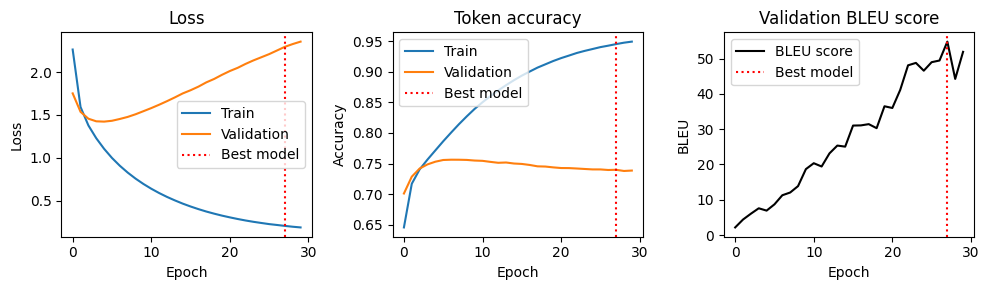

In [12]:
# Plot learning curves: loss, accuracy, and BLEU
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

# Epoch where best BLEU was achieved (model weights restored from here)
best_epoch = bleu_callback.best_epoch

# Left plot: training vs validation loss
# Overfitting visible when validation loss increases while training loss decreases
axes[0].set_title('Loss')
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='best')

# Middle plot: token-level accuracy
# Shows fraction of correctly predicted tokens (inflated by padding tokens)
axes[1].set_title('Token accuracy')
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

# Right plot: BLEU score over training
# Marker shows best checkpoint (weights restored from this epoch)
axes[2].set_title('Validation BLEU score')
axes[2].plot(bleu_callback.bleu_scores, c='black', label='BLEU score')
axes[2].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BLEU')
axes[2].legend(loc='best')

plt.tight_layout()
plt.show()

**Note:** The loss and accuracy curves show clear overfitting (validation plateaus while training improves), yet BLEU continues to increase. Why?

- **Loss/accuracy** are computed using **teacher forcing** - the model sees ground truth previous tokens
- **BLEU** evaluates **autoregressive generation** - the model sees its own predictions

These are fundamentally different tasks. A model can memorize training sequences (overfitting the teacher-forcing objective) while its ability to generate coherent translations continues improving as embeddings become richer and general translation patterns solidify.

## 4. Translation evaluation

For inference, we split the model into separate encoder and decoder models. The encoder runs once to produce the initial states, then the decoder runs autoregressively, feeding each predicted token back as input.

**Inference architecture:**

```text

  STEP 1: Encode (run once)                     STEP 2: Decode token by token

  Input: "Hello world"                                 ┌─────────────┐
          │                           t=0: <pad> ─────►│  Embedding  │
          ▼                                            └──────┬──────┘
   ┌─────────────┐                                            │
   │  Embedding  │                                            ▼
   └──────┬──────┘                                     ┌─────────────┐
          │                           [h₀,c₀] ────────►│    LSTM     │───► [h₁,c₁]
          ▼                                            └──────┬──────┘
  ┌───────────────┐                                           │
  │ Bidirectional │                                           ▼
  │     LSTM      │                                    ┌─────────────┐
  └───────┬───────┘                                    │   Dense     │───► "Bonjour"
          │                                            └─────────────┘
          ▼
      [h₀, c₀]

  t=0: <pad>     ──► Embedding ──► LSTM ──► Dense ──► "Bonjour" (using h₀,c₀)
  t=1: "Bonjour" ──► Embedding ──► LSTM ──► Dense ──► "monde"   (using h₁,c₁)
  t=2: "monde"   ──► Embedding ──► LSTM ──► Dense ──► </s>      (stop)
```

The decoder model takes one token at a time and outputs the next token prediction plus updated states. We repeat until the model outputs an end-of-sequence token or reaches the maximum length.

In [15]:
# Build final inference models for translation examples
encoder_model, decoder_model = build_inference_models_lstm(model, latent_dim=256)

# Evaluate on a larger sample than used during training callback
sample_indices = np.random.choice(len(pairs), size=min(200, len(pairs)), replace=False)

# Collect model predictions and ground truth
hypotheses = []  # Model translations
references = []  # Ground truth translations

print('Generating translations for BLEU evaluation...')

for i, idx in enumerate(sample_indices):

    en_text, fr_ref = pairs[idx]
    fr_hyp = translate_lstm(en_text, encoder_model, decoder_model, tokenizer, max_encoder_len, max_decoder_len)
    
    hypotheses.append(fr_hyp)
    references.append(fr_ref)
    
    # Progress indicator
    if (i + 1) % 50 == 0:
        print(f'  Processed {i + 1}/{len(sample_indices)} samples')

# Compute corpus-level BLEU (aggregates n-gram precision across all sentences)
bleu = BLEU()
result = bleu.corpus_score(hypotheses, [references])

print(f'\nBLEU score: {result.score:.2f}')
print(f'Breakdown: {result}')

# Qualitative analysis: inspect individual translations
print('\nSample predictions vs references:\n')

for i in range(10):

    print(f'  Source: {pairs[sample_indices[i]][0]}')
    print(f'  Reference: {references[i]}')
    print(f'  Hypothesis: {hypotheses[i]}\n')

Generating translations for BLEU evaluation...
  Processed 50/200 samples
  Processed 100/200 samples
  Processed 150/200 samples
  Processed 200/200 samples

BLEU score: 52.09
Breakdown: BLEU = 52.09 68.5/53.9/47.4/42.8 (BP = 0.995 ratio = 0.995 hyp_len = 1238 ref_len = 1244)

Sample predictions vs references:

  Source: - Your daughter.
  Reference: Votre fille.
  Hypothesis: Votre fille.

  Source: - I'm doing it for you!
  Reference: Il faut que tu en parles à tes parents.
  Hypothesis: Je fais de l'autre ici.

  Source: http://www.eclaireurs.org
  Reference: http://scouts.montigny.free.fr
  Hypothesis: http://scouts.montigny.free.fr

  Source: Are you deaf? !
  Reference: T'es sourde ?
  Hypothesis: T'es sourde ?

  Source: My poorfellow, it seems we aren't much different.
  Reference: Nous sommes logés à la même enseigne, mon vieux.
  Hypothesis: Nous sommes prises, une de ces meilleurs faciles.

  Source: I got to go.
  Reference: Je dois y aller.
  Hypothesis: Je dois y aller.
